In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [2]:
class BatsmanState(TypedDict):
    runs : int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [3]:
def calculate_sr(state: BatsmanState) -> BatsmanState:
    state["sr"] = (state["runs"] / state["balls"]) * 100
    return {"sr": state["sr"]}

In [4]:
def calculate_bpb(state: BatsmanState) -> BatsmanState:
    state["bpb"] = state["balls"] / (state["fours"] + state["sixes"])
    return {"bpb": state["bpb"]}

In [5]:
def calculate_boundary_percentage(state: BatsmanState) -> BatsmanState:
    state["boundary_percentage"] = ((state["fours"] + state["sixes"]) / state["balls"]) * 100
    return {"boundary_percentage": state["boundary_percentage"]}

In [6]:
def summary(state: BatsmanState) -> BatsmanState:
    summary = f"Strike Rate: {state['sr']:.2f}, Balls per Boundary: {state['bpb']:.2f}, Boundary Percentage: {state['boundary_percentage']:.2f}%"
    state["summary"] = summary
    return {"summary": state["summary"]}

In [7]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("calculate_boundary_percentage",calculate_boundary_percentage)
graph.add_node("summary",summary)

# edges
graph.add_edge(START,"calculate_sr")
graph.add_edge(START,"calculate_bpb")
graph.add_edge(START,"calculate_boundary_percentage")

graph.add_edge("calculate_sr","summary")
graph.add_edge("calculate_bpb","summary")
graph.add_edge("calculate_boundary_percentage","summary")

graph.add_edge("summary",END)

workflow = graph.compile()

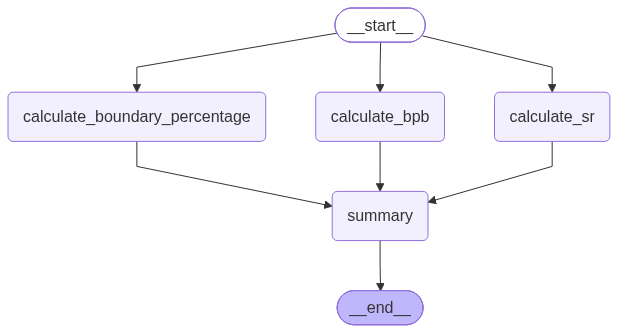

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [10]:
initial_state = {
    "runs": 100,
    "balls": 100,
    "fours": 10,
    "sixes": 5,
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 100,
 'fours': 10,
 'sixes': 5,
 'sr': 100.0,
 'bpb': 6.666666666666667,
 'boundary_percentage': 15.0,
 'summary': 'Strike Rate: 100.00, Balls per Boundary: 6.67, Boundary Percentage: 15.00%'}